In [1]:
pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [16]:
import torch
from captum.attr import IntegratedGradients
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

import sys
sys.path.append(os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/src/models/haven/haven.py"))

In [15]:
import torch.nn as nn
from models.baseline.nlp.transformer.multi_head_attention import MultiHeadAttention
from models.baseline.nlp.transformer.feed_forward_layer import FeedForwardLayer
from utils import nn_utils, constants
import torch
import torch.nn.functional as F
from models.protein_sequence_classification import ProteinSequenceClassification



ModuleNotFoundError: No module named 'models'

In [17]:
final = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/coronaviridae/20250616/final_filtered_df.csv")
df = pd.read_csv(final)
df

,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len,virus_host_tax_id_count
0,UniRef50_A0A5J6YH13,1586324,NaN,QFP39650.1,['pig'],pig,Porcine deltacoronavirus,no rank,9823,species,MQRALLIMTLLCLVRAKFADDLLDLLTFPGAHRFLHKLTSNSSSLY...,580,18
1,UniRef50_A0A0H3VE52,277944,[9606],AKA09614.1,['Homo sapiens'],homo sapiens,Human coronavirus NL63,species,9606,species,VLPLASCFFTCNSNANLSMLQLGVPDNSSTIVTGLLPTHWICANQS...,253,122
2,UniRef50_A0A5P9K482,28295,NaN,QFU19298.1,['swine'],swine,Porcine epidemic diarrhea virus,species,9823,species,VTXGRNCLFNKAIPAHMQDGXNXVXGITWDNDRVTVFXDKIYHFYX...,491,18
3,UniRef50_A0A0H3VFW7,31631,[9606],AKA09662.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species,AFAVIGDLKCPLDTSRKGSFNNKDTGPPFISTDTVDVTNGLGTYYV...,272,122
4,UniRef50_A0A5Q2USU7,11120,NaN,QGH51289.1,['Gallus gallus'],gallus gallus,Infectious bronchitis virus,no rank,9031,species,MLKKSLFLVTILCALCSANLFDPANTYVYYYQSAFKPPNGWPPRGG...,280,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,UniRef50_W6EA71,28295,NaN,AHJ11039.1,['pig'],pig,Porcine epidemic diarrhea virus,species,9823,species,MASVSFQDRGRKRVPLSLYAPLRVTNDKPLSKVLANNAVPTNKGNN...,349,18
258,UniRef50_N1NTJ5,12663,NaN,CCW59376.1,['Felis catus'],felis catus,Feline coronavirus,no rank,9685,species,AQAAVINDEIVGAITAVNQTDLFEFVNHTQSRRSRRSASSSVTTYT...,52,35
259,UniRef50_X5CNV6,694014,NaN,AHW48920.1,['chicken'],chicken,Avian coronavirus,species,9031,species,NTTLKLTNFTFTNVSNASPNSGGVHTFQLYQTSTAQNGYYNFNFSF...,83,60
260,UniRef50_X5D4P7,11120,NaN,AHW49209.1,['chicken'],chicken,Infectious bronchitis virus,no rank,9031,species,YRVVNTTNLTASTCSLGGVPNLVEVNTPAVTIASPSRLPWSKANFT...,174,60


In [22]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/epochs40_60_patience_30.csv")
epoch100 = pd.read_csv(file_path)
epoch100

epoch100['uniref50_id'] = df['uniref50_id']
final = epoch100.merge(df[['uniref50_id', 'seq']], on='uniref50_id')
final

,Unnamed: 0,Cat,Chicken,European rabbit,Gray wolf,Human,Pig,y_true,itr,uniref50_id,seq
0,0,0.569137,0.092541,0.101969,0.135346,0.036523,0.064485,Human,0,UniRef50_A0A5J6YH13,MQRALLIMTLLCLVRAKFADDLLDLLTFPGAHRFLHKLTSNSSSLY...
1,1,0.630755,0.121122,0.088202,0.098533,0.018917,0.042471,Cat,0,UniRef50_A0A0H3VE52,VLPLASCFFTCNSNANLSMLQLGVPDNSSTIVTGLLPTHWICANQS...
2,2,0.112685,0.008332,0.198174,0.108836,0.302285,0.269689,Human,0,UniRef50_A0A5P9K482,VTXGRNCLFNKAIPAHMQDGXNXVXGITWDNDRVTVFXDKIYHFYX...
3,3,0.482172,0.231771,0.078845,0.085245,0.061163,0.060804,Chicken,0,UniRef50_A0A0H3VFW7,AFAVIGDLKCPLDTSRKGSFNNKDTGPPFISTDTVDVTNGLGTYYV...
4,4,0.026982,0.020275,0.054023,0.053659,0.770988,0.074073,Human,0,UniRef50_A0A5Q2USU7,MLKKSLFLVTILCALCSANLFDPANTYVYYYQSAFKPPNGWPPRGG...
...,...,...,...,...,...,...,...,...,...,...,...
130,22,0.156593,0.038792,0.172112,0.286937,0.283893,0.061673,Human,4,UniRef50_A0A8B6RKA7,MFHLVDFQVTIAEILLIIMRTFKVSIWNLDYIINLXXXXXXXXXXX...
131,23,0.081046,0.001294,0.133650,0.040270,0.671416,0.072325,Human,4,UniRef50_A0A8B6RKH9,MFHLVDFQVTIAEILLIIMRTFKVSIWNXXXXXXXXXXXXXXXXXX...
132,24,0.036666,0.254386,0.096855,0.272912,0.115845,0.223336,Chicken,4,UniRef50_A0A8B6RKW5,VXXXXXIFWFSLELQDHNETCHA
133,25,0.139783,0.208992,0.094913,0.157980,0.328311,0.070021,Human,4,UniRef50_A0A8B6RLZ0,MFHLVDFQVTIAEILLIIMRTFKVSIWNLDXXXXXXXXXXXXXXXX...


In [29]:
# target_host = "Chicken"
# k = 5

# kmer_probs = defaultdict(list)

# # Loop through sequences and predictions
# for _, row in final.iterrows():
#     seq = row['seq']
#     prob = row[target_host]

#     for i in range(len(seq) - k + 1):
#         kmer = seq[i:i+k]
#         kmer_probs[kmer].append(prob)

# # Average the scores per k-mer
# avg_kmer_scores = {kmer: sum(vals)/len(vals) for kmer, vals in kmer_probs.items() if len(vals) >= 3}

# # Sort to find most influential k-mers
# top_kmers = sorted(avg_kmer_scores.items(), key=lambda x: x[1], reverse=True)

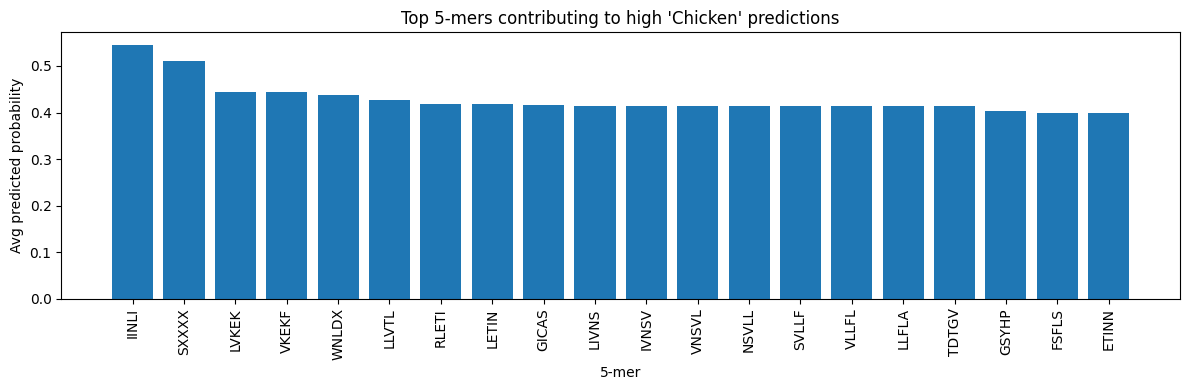

In [30]:
# import matplotlib.pyplot as plt

# top_n = 20
# top_kmers_slice = top_kmers[:top_n]
# kmers, scores = zip(*top_kmers_slice)

# plt.figure(figsize=(12, 4))
# plt.bar(kmers, scores)
# plt.title(f"Top {k}-mers contributing to high '{target_host}' predictions")
# plt.ylabel("Avg predicted probability")
# plt.xlabel(f"{k}-mer")
# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()

# KMERS
Kmers are substring of length k.
k = 5, are called 5mers
if we are having a kmer of 5 for a protein sequence, we are getting a 5 lettered protein sequence
In the above graph, we are seeing which 5mers are most common in chicken predictions
tokenizing protein sequence into kmeres